[&#8592; Previous: Supervised Learning](04_supervised_learning.ipynb)

# **Supervised Learning Extensions**

---

This notebook **extends `04_supervised_learning.ipynb`** and re-checks its **cross-sectional
MIPS increment** under two refinements: **population weighting** (does the small association hold
where most beneficiaries live?) and **PCA features** (does it need the individual correlated
measures?). Each section explains its own setup below.

> **Note:** run `04_supervised_learning.ipynb` first; it exports the modeling frame this notebook loads.

**Setup:** Pinned dependencies: `python -m pip install -r ../requirements.txt`

## Table of Contents

1. [Setup and load the modeling frame](#se1)
2. [Extension A: population weighted models](#se2)
3. [Extension B: PCA feature variant](#se3)
4. [Extension C: spatial standard errors](#se4)
5. [Summary](#se5)

---
<a id="se1"></a>

## **1. Setup and load the modeling frame**

Everything comes from the main notebook's export: same counties, same 49 screened measures, same
controls, same fold construction (the frame is sorted by county FIPS, so GroupKFold reproduces the
identical splits).

In [1]:
# Standard Library
import json
from pathlib import Path

# Data Processing
import numpy as np
import polars as pl

# Machine Learning
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score

DATA = Path("../data")
RANDOM_STATE = 42
MODEL_YEAR = "2023"
N_SPLITS = 5
PRIMARY_TARGET = "ACUTE_HOSP_READMSN_PCT"

# Exported by 04-supervised-learning.ipynb (run that first)
frame = pl.read_parquet(DATA / "interim" / f"modeling_frame_{MODEL_YEAR}.parquet")
meta = json.loads((DATA / "interim" / f"modeling_metadata_{MODEL_YEAR}.json").read_text())
CONTROLS = meta["controls"]
final_measures = meta["final_measures"]
FEATURE_SETS = meta["feature_sets"]

assert frame.height == 2507, f"unexpected frame size: {frame.height}"
assert len(final_measures) == 49

sub = frame.filter(pl.col(PRIMARY_TARGET).is_not_null()).sort("county_fips")
X_all = sub.select(FEATURE_SETS["controls_plus_mips"]).to_pandas()
y = sub[PRIMARY_TARGET].to_numpy()
groups = sub["state"].to_numpy()
weights = np.exp(sub["log_benes"].to_numpy())
folds = list(GroupKFold(n_splits=N_SPLITS).split(X_all, y, groups))

MODELS = {
    "linear": lambda: LinearRegression(),
    "elastic_net": lambda: ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 1.0], alphas=50,
                                        max_iter=5000, random_state=RANDOM_STATE),
    "random_forest": lambda: RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                                   n_jobs=-1, random_state=RANDOM_STATE),
    "grad_boost": lambda: HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

def make_pipe(model):
    """Wrap an estimator with the shared preprocessing steps.

    Args:
        model: An unfitted sklearn estimator.

    Returns:
        Pipeline of median imputation, standardization, then the model, so
        preprocessing is fitted inside each training fold only.
    """
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", model),
    ])

print(f"panel: {len(y):,} counties, {len(final_measures)} measures, {sub['state'].n_unique()} states")
print(f"beneficiary counts: min={weights.min():,.0f}  median={np.median(weights):,.0f}  max={weights.max():,.0f}")

panel: 2,458 counties, 49 measures, 51 states
beneficiary counts: min=211  median=9,175  max=1,678,944


---
<a id="se2"></a>

## **2. Extension A: population weighted models**

Same models and folds, but each county's fit contribution is weighted by its beneficiary population
(imputation and scaling stay per county, so features match the main notebook). Test fold R2 stays
unweighted for comparability. If the lift survives weighting, it is not just an artifact of noisy
small counties.

In [2]:
def weighted_cv(model_factory, X, y, w, folds):
    """Cross-validate a pipeline with per-county sample weights.

    Args:
        model_factory: Zero-argument callable returning an unfitted estimator.
        X: Feature DataFrame.
        y: Target array.
        w: Sample weights, one per row of X (beneficiary counts here).
        folds: List of (train_idx, test_idx) pairs.

    Returns:
        Array of unweighted test-fold R2 scores, one per fold, so results
        stay comparable with the unweighted runs in the main notebook.
    """
    scores = []
    for tr, te in folds:
        pipe = make_pipe(model_factory())
        pipe.fit(X.iloc[tr], y[tr], model__sample_weight=w[tr])
        scores.append(r2_score(y[te], pipe.predict(X.iloc[te])))
    return np.array(scores)

records = []
for m_name, m_factory in MODELS.items():
    r2 = {}
    for fs_name, feats in FEATURE_SETS.items():
        # Unweighted reference (mirrors the main notebook)
        cv_u = cross_validate(make_pipe(m_factory()), X_all[feats], y, cv=folds,
                              scoring={"r2": "r2"}, error_score="raise")
        # Weighted fit, unweighted scoring
        r2[fs_name] = {
            "unweighted": cv_u["test_r2"].mean(),
            "weighted": weighted_cv(m_factory, X_all[feats], y, weights, folds).mean(),
        }
    for kind in ("unweighted", "weighted"):
        records.append({
            "model": m_name, "fit": kind,
            "r2_controls": r2["controls_only"][kind],
            "r2_full": r2["controls_plus_mips"][kind],
            "delta_r2": r2["controls_plus_mips"][kind] - r2["controls_only"][kind],
        })

weighted_tbl = pl.DataFrame(records)
with pl.Config(float_precision=4, tbl_rows=20):
    print(weighted_tbl)

shape: (8, 5)
┌───────────────┬────────────┬─────────────┬─────────┬──────────┐
│ model         ┆ fit        ┆ r2_controls ┆ r2_full ┆ delta_r2 │
│ ---           ┆ ---        ┆ ---         ┆ ---     ┆ ---      │
│ str           ┆ str        ┆ f64         ┆ f64     ┆ f64      │
╞═══════════════╪════════════╪═════════════╪═════════╪══════════╡
│ linear        ┆ unweighted ┆ 0.1264      ┆ 0.1171  ┆ -0.0093  │
│ linear        ┆ weighted   ┆ 0.1307      ┆ 0.1172  ┆ -0.0134  │
│ elastic_net   ┆ unweighted ┆ 0.1295      ┆ 0.1469  ┆ 0.0174   │
│ elastic_net   ┆ weighted   ┆ 0.1339      ┆ 0.1509  ┆ 0.0170   │
│ random_forest ┆ unweighted ┆ 0.1434      ┆ 0.1565  ┆ 0.0131   │
│ random_forest ┆ weighted   ┆ 0.1707      ┆ 0.1761  ┆ 0.0054   │
│ grad_boost    ┆ unweighted ┆ 0.0823      ┆ 0.1024  ┆ 0.0202   │
│ grad_boost    ┆ weighted   ┆ 0.1180      ┆ 0.1368  ┆ 0.0188   │
└───────────────┴────────────┴─────────────┴─────────┴──────────┘


---
<a id="se3"></a>

## **3. Extension B: PCA feature variant**

The 49 measures are replaced by principal components capturing 90% of their variance. The PCA is
fitted **inside each training fold** (never on test states), controls pass through untouched, and
the same fold structure applies. This mirrors the unsupervised notebook, where the same
dimensionality reduction found preventive care as the dominant axis; component-level results
should be read against its loadings.

In [3]:
def make_pca_pipe(model, controls, measures):
    """Build a pipeline that replaces the MIPS measures with principal components.

    Args:
        model: An unfitted sklearn estimator.
        controls: Control column names, passed through imputation and scaling only.
        measures: Measure column names, reduced to components explaining 90% of
            variance, fitted on training folds only.

    Returns:
        Pipeline of a ColumnTransformer (controls scaled, measures scaled then
        PCA-reduced) followed by the model.
    """
    ctrl_block = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    measure_block = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=0.90, random_state=RANDOM_STATE)),
    ])
    features = ColumnTransformer([
        ("controls", ctrl_block, controls),
        ("measures", measure_block, measures),
    ])
    return Pipeline([("features", features), ("model", model)])

ctrl_feats = FEATURE_SETS["controls_only"]

records = []
for m_name, m_factory in MODELS.items():
    cv_ctrl = cross_validate(make_pipe(m_factory()), X_all[ctrl_feats], y, cv=folds,
                             scoring={"r2": "r2"}, error_score="raise")
    cv_pca = cross_validate(make_pca_pipe(m_factory(), ctrl_feats, final_measures),
                            X_all, y, cv=folds, scoring={"r2": "r2"}, error_score="raise")
    records.append({
        "model": m_name,
        "r2_controls": cv_ctrl["test_r2"].mean(),
        "r2_controls_plus_pca": cv_pca["test_r2"].mean(),
        "delta_r2_pca": cv_pca["test_r2"].mean() - cv_ctrl["test_r2"].mean(),
    })

pca_tbl = pl.DataFrame(records)
with pl.Config(float_precision=4):
    print(pca_tbl)

# Reference: how many components a full-panel fit keeps at the 90% threshold
probe = make_pca_pipe(LinearRegression(), ctrl_feats, final_measures)
probe.fit(X_all, y)
n_comp = probe.named_steps["features"].named_transformers_["measures"].named_steps["pca"].n_components_
print(f"components kept at 90% variance (full-panel reference): {n_comp} of {len(final_measures)} measures")

shape: (4, 4)
┌───────────────┬─────────────┬──────────────────────┬──────────────┐
│ model         ┆ r2_controls ┆ r2_controls_plus_pca ┆ delta_r2_pca │
│ ---           ┆ ---         ┆ ---                  ┆ ---          │
│ str           ┆ f64         ┆ f64                  ┆ f64          │
╞═══════════════╪═════════════╪══════════════════════╪══════════════╡
│ linear        ┆ 0.1264      ┆ 0.1300               ┆ 0.0037       │
│ elastic_net   ┆ 0.1295      ┆ 0.1405               ┆ 0.0110       │
│ random_forest ┆ 0.1434      ┆ 0.1353               ┆ -0.0081      │
│ grad_boost    ┆ 0.0823      ┆ 0.1006               ┆ 0.0183       │
└───────────────┴─────────────┴──────────────────────┴──────────────┘
components kept at 90% variance (full-panel reference): 39 of 49 measures


---
<a id="se4"></a>

## **4. Extension C: spatial standard errors**

Notebook 04 section 11 measured residual spatial autocorrelation (Moran's I ~ +0.20, perm p = 0.001)
and stopped there. This extension follows it through. Neighbouring counties resemble each other, so
they are not independent observations, and the measure-level intervals in notebook 04 section 10
assume they are once you look across state lines.

Clustering by **state** absorbs correlation within a state but treats states as independent of each
other, which cross-border resemblance violates. Two alternatives, each re-fitting the same per-measure
models on the same sample so only the standard error changes:

- **Census division (9 groups)** pools neighbouring states into one cluster, so cross-border pairs
  fall inside a cluster. The cost is severe: cluster-robust inference wants roughly 30+ groups, and
  at 9 the estimator is itself unreliable, so read it as a stress test rather than a correction.
- **Conley spatial HAC** lets covariance decay with distance under a Bartlett kernel, with no cluster
  count to run out of. This is the estimator built for exactly this problem.

Coefficients are identical under all three, since the choice of standard error never moves a point
estimate. Only the width of the intervals changes, and with it which measures clear FDR.


spatial sample: 2,436 of 2,507 counties (47 states, 9 census divisions)
eligible measures above the 70% coverage floor: 16
  survive BH-FDR under state    : 3
  survive BH-FDR under division : 1
  survive BH-FDR under conley   : 3
shape: (6, 8)
┌────────────────┬──────────┬──────────┬─────────────┬───────────┬─────────┬────────────┬──────────┐
│ feature        ┆ coef     ┆ se_state ┆ se_division ┆ se_conley ┆ q_state ┆ q_division ┆ q_conley │
│ ---            ┆ ---      ┆ ---      ┆ ---         ┆ ---       ┆ ---     ┆ ---        ┆ ---      │
│ str            ┆ f64      ┆ f64      ┆ f64         ┆ f64       ┆ f64     ┆ f64        ┆ f64      │
╞════════════════╪══════════╪══════════╪═════════════╪═══════════╪═════════╪════════════╪══════════╡
│ MIPS_GRP_001_o ┆ -0.00286 ┆ 0.00083  ┆ 0.00110     ┆ 0.00063   ┆ 0.00559 ┆ 0.06532    ┆ 0.00009  │
│ verall         ┆          ┆          ┆             ┆           ┆         ┆            ┆          │
│ MIPS_GRP_309_o ┆ -0.00237 ┆ 0.00070  ┆ 0.00069

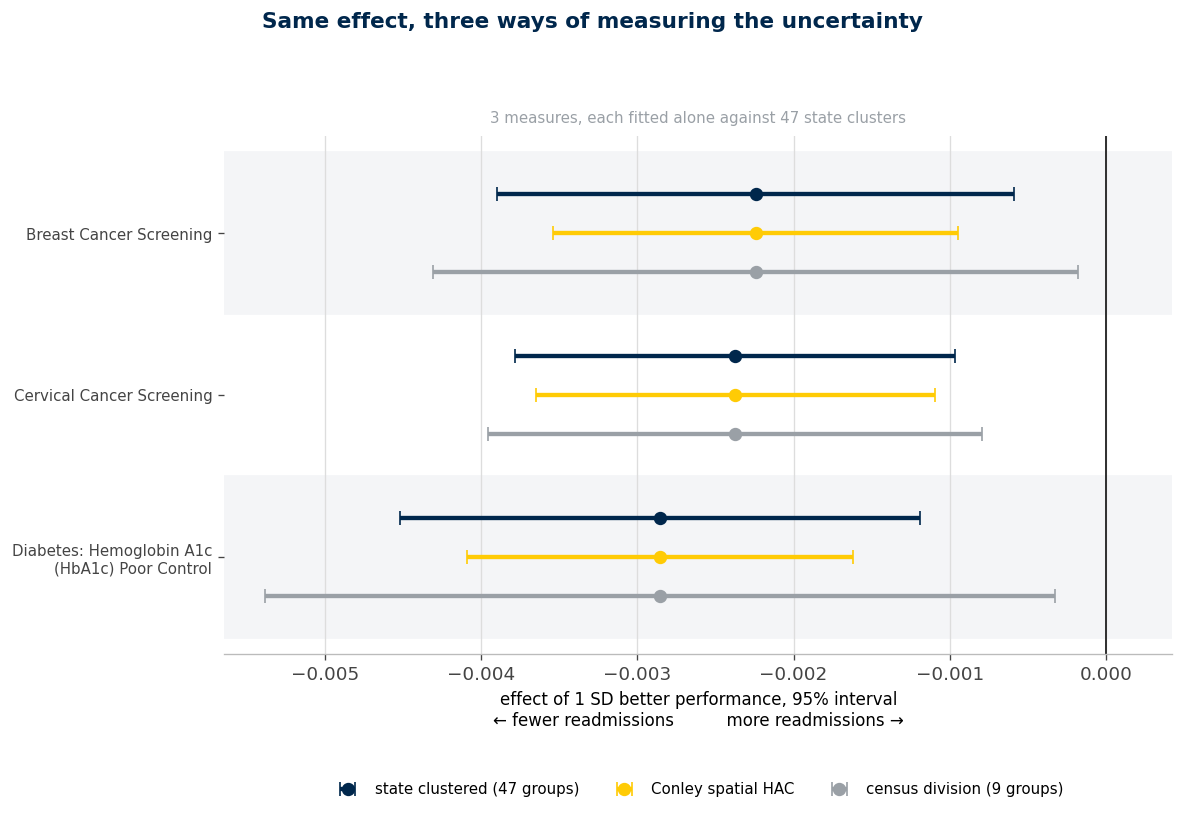

In [4]:
import re
from scipy import stats as sstats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

# The setup cell does not pull flip_sign out of the metadata; this section needs it
# to sign-align coefficients the same way notebook 04 section 10 does.
flip_sign = meta["flip_sign"]

# Centroids exported by notebook 04 (contiguous US only, so the spatial sample is
# slightly smaller than the modelling sample).
cent = pl.read_csv(DATA / "interim" / f"county_centroids_{MODEL_YEAR}.csv",
                   schema_overrides={"county_fips": pl.String})
spatial = (frame
           .join(cent, on="county_fips", how="inner")
           .filter(pl.col(PRIMARY_TARGET).is_not_null())
           .sort("county_fips"))

# US Census divisions, keyed by state FIPS. Pools neighbouring states so that
# cross-border county pairs land inside the same cluster.
CENSUS_DIVISION = {
    "09": 1, "23": 1, "25": 1, "33": 1, "44": 1, "50": 1,
    "34": 2, "36": 2, "42": 2,
    "17": 3, "18": 3, "26": 3, "39": 3, "55": 3,
    "19": 4, "20": 4, "27": 4, "29": 4, "31": 4, "38": 4, "46": 4,
    "10": 5, "11": 5, "12": 5, "13": 5, "24": 5, "37": 5, "45": 5, "51": 5, "54": 5,
    "01": 6, "21": 6, "28": 6, "47": 6,
    "05": 7, "22": 7, "40": 7, "48": 7,
    "04": 8, "08": 8, "16": 8, "30": 8, "32": 8, "35": 8, "49": 8, "56": 8,
    "06": 9, "41": 9, "53": 9,
}
state_g = spatial["state"].to_numpy()
div_g = np.array([CENSUS_DIVISION[s] for s in spatial["state"].to_list()])

# Pairwise great-circle distances in km, equirectangular approximation. Same
# cos(latitude) correction the Moran's I cell uses so the geometry is consistent.
lonlat = spatial.select("lon", "lat").to_numpy()
lat0 = np.deg2rad(lonlat[:, 1].mean())
xy = np.column_stack([lonlat[:, 0] * np.cos(lat0) * 111.32, lonlat[:, 1] * 110.57])
DIST_KM = np.sqrt(((xy[:, None, :] - xy[None, :, :]) ** 2).sum(-1))

CONLEY_CUTOFF_KM = 200.0

def conley_bse(X, resid, cutoff_km=CONLEY_CUTOFF_KM):
    """Conley spatial HAC standard errors with a Bartlett distance kernel.

    Covariance between two counties is weighted by 1 - d/cutoff and vanishes
    beyond the cutoff, so nearby counties are allowed to be correlated without
    assuming anything about state boundaries.

    Args:
        X: Design matrix including the constant, aligned to DIST_KM.
        resid: OLS residual vector.
        cutoff_km: Distance beyond which covariance is taken to be zero.

    Returns:
        Array of standard errors, one per column of X.
    """
    Xn = np.asarray(X, dtype=float)
    W = np.maximum(0.0, 1.0 - DIST_KM / cutoff_km)
    Xe = Xn * np.asarray(resid)[:, None]
    bread = np.linalg.inv(Xn.T @ Xn)
    V = bread @ (Xe.T @ W @ Xe) @ bread
    dof = Xn.shape[0] / (Xn.shape[0] - Xn.shape[1])   # match statsmodels' finite-sample scaling
    return np.sqrt(np.diag(V) * dof)

y_sp = spatial[PRIMARY_TARGET].cast(pl.Float64).to_numpy()
X_sp = spatial.select(FEATURE_SETS["controls_plus_mips"]).to_pandas()

def standardized_design(feats):
    """Median-impute, standardize, and sign-align, matching notebook 04 section 10."""
    Z = X_sp[feats].copy()
    Z = Z.fillna(Z.median(numeric_only=True))
    Z = (Z - Z.mean()) / Z.std(ddof=0)
    for col, sign in flip_sign.items():
        if col in Z.columns and sign < 0:
            Z[col] = -Z[col]
    return sm.add_constant(Z)

CTRL_FEATS = FEATURE_SETS["controls_only"]
rows = []
for m in final_measures:
    Z = standardized_design(CTRL_FEATS + [m])
    j = list(Z.columns).index(m)
    base = sm.OLS(y_sp, Z).fit()
    se_conley = conley_bse(Z, base.resid)[j]
    fits = {"state": sm.OLS(y_sp, Z).fit(cov_type="cluster", cov_kwds={"groups": state_g}),
            "division": sm.OLS(y_sp, Z).fit(cov_type="cluster", cov_kwds={"groups": div_g})}
    z_conley = float(base.params[m]) / se_conley
    rows.append({
        "feature": m,
        "coef": float(base.params[m]),
        "pct_observed": round(100 * (1 - X_sp[m].isna().mean()), 1),
        "se_state": float(fits["state"].bse[m]),
        "se_division": float(fits["division"].bse[m]),
        "se_conley": float(se_conley),
        "p_state": float(fits["state"].pvalues[m]),
        "p_division": float(fits["division"].pvalues[m]),
        "p_conley": 2 * (1 - sstats.norm.cdf(abs(z_conley))),
    })

# Same 70% coverage floor as notebook 04, applied before FDR for the same reason.
spatial_tbl = pl.DataFrame(rows).filter(pl.col("pct_observed") >= 70.0)
for kind in ("state", "division", "conley"):
    spatial_tbl = spatial_tbl.with_columns(
        pl.Series(f"q_{kind}", multipletests(spatial_tbl[f"p_{kind}"].to_numpy(), method="fdr_bh")[1]))

print(f"spatial sample: {spatial.height:,} of {frame.height:,} counties "
      f"({len(set(state_g))} states, {len(set(div_g))} census divisions)")
print(f"eligible measures above the 70% coverage floor: {spatial_tbl.height}")
for kind in ("state", "division", "conley"):
    print(f"  survive BH-FDR under {kind:9}: {int((spatial_tbl[f'q_{kind}'] < 0.05).sum())}")

with pl.Config(tbl_rows=8, float_precision=5, tbl_cols=10):
    print(spatial_tbl.sort("q_state").select(
        "feature", "coef", "se_state", "se_division", "se_conley",
        "q_state", "q_division", "q_conley").head(6))

# Is the Conley result an artifact of the 200 km cutoff? Re-run across a wide range.
print("\nConley SE vs kernel cutoff (the three measures that clear FDR in notebook 04):")
headline = spatial_tbl.sort("q_state")["feature"].to_list()[:3]
print(f"  {'cutoff km':>10} " + " ".join(f"{h.split('_')[2]:>9}" for h in headline))
for cut in (100.0, 200.0, 500.0, 1000.0, 2000.0):
    out = []
    for m in headline:
        Z = standardized_design(CTRL_FEATS + [m])
        base = sm.OLS(y_sp, Z).fit()
        out.append(conley_bse(Z, base.resid, cut)[list(Z.columns).index(m)])
    print(f"  {cut:10.0f} " + " ".join(f"{v:9.5f}" for v in out))

spatial_tbl.write_csv(DATA / "interim" / f"extension_spatial_{MODEL_YEAR}.csv")

# Forest plot. Titles describe what the chart shows; every number in them is computed
# from the data above, so nothing here can go stale if the analysis changes.
import matplotlib.pyplot as plt

FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)
BLUE, MAIZE, GRAY = "#00274C", "#FFCB05", "#9aa0a6"
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
    "svg.hashsalt": "healthcare-heroes", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": BLUE,
    "axes.edgecolor": "#bbbbbb", "xtick.color": "#444444", "ytick.color": "#444444",
})

# Readable labels come from the coefficient table notebook 04 exports, so they are not
# hardcoded here and follow the analysis if the surviving set changes.
titles = dict(
    pl.read_csv(DATA / "interim" / f"coef_table_{MODEL_YEAR}.csv")
      .select("feature", "measure_title").drop_nulls().iter_rows()
)

def wrap_label(code, width=26):
    """Short measure title over at most two lines, falling back to the code."""
    title = titles.get(code, code)
    title = re.sub(r"\s*\([^()]*\)\s*$", "", title).strip()   # trailing qualifier only, e.g. "(>9%)"
    words, lines, cur = title.split(), [], ""
    for w in words:
        if len(cur) + len(w) + 1 > width:
            lines.append(cur); cur = w
        else:
            cur = f"{cur} {w}".strip()
    lines.append(cur)
    return "\n".join(lines[:2])

# Critical values differ by estimator: cluster-robust uses t with (groups - 1) df,
# Conley is asymptotically normal.
CRIT = {"state":    sstats.t.ppf(0.975, len(set(state_g)) - 1),
        "division": sstats.t.ppf(0.975, len(set(div_g)) - 1),
        "conley":   sstats.norm.ppf(0.975)}
STYLE = {"state":    (BLUE,  f"state clustered ({len(set(state_g))} groups)"),
         "conley":   (MAIZE, "Conley spatial HAC"),
         "division": (GRAY,  f"census division ({len(set(div_g))} groups)")}

# Show the measures that clear FDR under the baseline estimator, so the figure answers
# "do these survive the alternatives" rather than showing every measure tested.
shown = spatial_tbl.filter(pl.col("q_state") < 0.05).sort("coef")
offsets = {"state": 0.24, "conley": 0.0, "division": -0.24}

fig, ax = plt.subplots(figsize=(10, 1.7 * shown.height + 2.2))
for row in range(shown.height):                      # banding groups the three estimators
    if row % 2 == 0:
        ax.axhspan(row - 0.5, row + 0.5, color="#f4f5f7", zorder=0)
for kind, (color, legend) in STYLE.items():
    ax.errorbar(shown["coef"].to_numpy(), np.arange(shown.height) + offsets[kind],
                xerr=CRIT[kind] * shown[f"se_{kind}"].to_numpy(),
                fmt="o", markersize=7, color=color, ecolor=color,
                elinewidth=2.6, capsize=4, label=legend, zorder=3)
ax.axvline(0, color="#333333", linewidth=1.2, zorder=2)
ax.set_yticks(np.arange(shown.height), [wrap_label(f) for f in shown["feature"].to_list()],
              fontsize=9)
ax.set_ylim(-0.6, shown.height - 0.4)
lo, hi = ax.get_xlim()                      # keep zero inside the frame, not on the spine
ax.set_xlim(lo, max(hi, 0) + (hi - lo) * 0.06)
ax.set_xlabel("effect of 1 SD better performance, 95% interval\n"
              "\u2190 fewer readmissions          more readmissions \u2192", fontsize=10)
ax.set_title(f"{shown.height} measures, each fitted alone against {len(set(state_g))} state clusters",
             fontsize=9, fontweight="normal", color=GRAY, pad=8)
fig.suptitle("Same effect, three ways of measuring the uncertainty",
             fontsize=13, fontweight="bold", color=BLUE, y=0.985)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, fontsize=9, frameon=False)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.grid(axis="x", color="#dddddd", linewidth=0.8, zorder=1)
ax.set_axisbelow(True)
fig.tight_layout(rect=[0, 0.02, 1, 0.94])
fig.savefig(FIGURES / "sl_spatial_forest.png")
fig.savefig(FIGURES / "sl_spatial_forest.svg", metadata={"Date": None})
plt.show()


---
<a id="se5"></a>

## **5. Summary**

- **Weighting.** The lift survives, most cleanly for Elastic Net (+0.017 unweighted and weighted);
  gradient boosting holds (~+0.019) and random forest shrinks most (+0.013 to +0.005), so the tree
  gain is the least stable. Lead with Elastic Net.
- **Spatial errors.** Conley spatial HAC errors are at or below the state-clustered ones and stable
  from a 100 km to a 2,000 km kernel, so the residual Moran's I of +0.20 does not make the notebook 04
  intervals optimistic; the same three measures clear FDR. Clustering at census division leaves one,
  but 9 groups is below what cluster-robust inference needs, so treat it as a caution not a refutation.
- **PCA.** ~39 components hold 90% of the variance. Decorrelating does not help: the Elastic Net
  increment falls to +0.011 and gradient boosting to +0.018. The useful point is that plain linear
  turns positive once measures are decorrelated, which is consistent with multicollinearity rather
  than a need for nonlinear models. Components are not named measures, so read them against the
  unsupervised loadings.

Neither extension overturns the headline: the MIPS increment stays small, cleanest under Elastic Net.
The stronger conclusion, that it adds essentially nothing beyond a county's own prior-year outcomes, is established in
`04_supervised_learning` (not re-tested here); see it for limitations and next steps.

In [5]:
# artifacts for the report draft
out_w = DATA / "interim" / f"extension_weighted_{MODEL_YEAR}.csv"
out_p = DATA / "interim" / f"extension_pca_{MODEL_YEAR}.csv"
weighted_tbl.write_csv(out_w)
pca_tbl.write_csv(out_p)
print(f"wrote {out_w}")
print(f"wrote {out_p}")
print("done")

wrote ../data/interim/extension_weighted_2023.csv
wrote ../data/interim/extension_pca_2023.csv
done


---
[&#8592; Back: Supervised Learning](04_supervised_learning.ipynb)  |  [Start over: Loading the Raw Data](01_loading_data.ipynb)

*End of the pipeline.*
